In [43]:
!pip3 install gliner

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [44]:
import pandas as pd

df = pd.read_csv("data/output_raw/raw_matched_food_prices.csv")
df

,category,name,price_value,quantity,dietary
0,fruits-vegetables,France Legend Apple,5.90,700g,NaN
1,fruits-vegetables,Holland Potato (China),1.40,1kg,NaN
2,fruits-vegetables,Malaysia Natural Fresh Japanese Cucumber,1.80,400g,NaN
3,fruits-vegetables,Fresh Blueberries,3.95,125g,NaN
4,fruits-vegetables,Chef Red Onion - Large,1.70,700g,NaN
...,...,...,...,...,...
4678,frozen,Hego Lamb Shabu Shabu,13.90,300 G,NaN
4679,frozen,Kee Song Frozen CaroGold Chicken Wing,12.91,500 G,NaN
4680,frozen,Blue Oceans Boontong Fish (Whole Clean 8-10),12.00,1 KG,NaN
4681,frozen,Royal Delights Curry Potato Samosa,11.00,1.2 KG,NaN


In [45]:
import re


def normalize_row(row):
    q = row.get('quantity')
    # isinstance guards the blank cells: a missing quantity reads as float nan,
    # which is truthy, so a plain `if q:` would try to lower() a float.
    if isinstance(q, str) and q:
        row['quantity'] = q.replace(" ", "").lower()
    return row


def clean_span(value):
    """A span as it is keyed on: the entity columns hold "" where NER found
    nothing, but an absent one reads as nan, which str() would spell "nan"."""
    return "" if pd.isna(value) else str(value).lower().strip()


QUANTITY_UNITS = {"kg": 1000.0, "g": 1.0, "mg": 0.001,
                  "l": 1000.0, "ml": 1.0, "lb": 453.592, "oz": 28.3495}

PACK_NOTE_RE = re.compile(r"\((?:ctn|[\d-]+(?:perpack|pcs|pc|s))\)", re.I)
AMOUNT_RE = re.compile(r"^(?:(\d+)x)?([\d.]+)(kg|g|mg|l|ml|lb|oz)$", re.I)


def parse_quantity(quantity):
    """A pack size as its magnitude in grams / millilitres, or None.

    No per-unit price for s, perpack, pc
    """
    text = PACK_NOTE_RE.sub("", quantity)       # isolate pack regex (for example 550g(10perpack) - care only 550g)
    total = 0.0

    for part in text.split("+"):
        match = AMOUNT_RE.match(part)           # extract number from amount regex
        if not match:
            return None
        count, amount, unit = match.groups()
        total += int(count or 1) * float(amount) * QUANTITY_UNITS[unit.lower()]
    return total or None


def prepare_listings(frame):
    """A crawl as the rest of the notebook wants it: quantity replaced by the
    magnitude it names, in grams / millilitres, and the listings that name no
    amount dropped.

    Done here so the parsed number is what products_prices_fairprice.csv holds:
    nothing after this reads a pack label again. "550g(10perpack)" is stored as
    550.0 and "5x125ml" as 625.0; a count-only pack ("1s", "6perpack", "1pc")
    has no magnitude to price per 100g, so the listing goes.
    """
    frame = frame.apply(normalize_row, axis=1)
    quantity = frame["quantity"].apply(lambda q: parse_quantity(clean_span(q)))
    kept = quantity.notna()
    print(f"dropping {(~kept).sum()} of {len(frame)} listings on a count-only pack")
    return frame.loc[kept].assign(quantity=quantity[kept]).reset_index(drop=True)


In [46]:
df = prepare_listings(df)
df


dropping 193 of 4683 listings on a count-only pack


,category,name,price_value,quantity,dietary
0,fruits-vegetables,France Legend Apple,5.90,700.0,NaN
1,fruits-vegetables,Holland Potato (China),1.40,1000.0,NaN
2,fruits-vegetables,Malaysia Natural Fresh Japanese Cucumber,1.80,400.0,NaN
3,fruits-vegetables,Fresh Blueberries,3.95,125.0,NaN
4,fruits-vegetables,Chef Red Onion - Large,1.70,700.0,NaN
...,...,...,...,...,...
4485,frozen,Hego Lamb Shabu Shabu,13.90,300.0,NaN
4486,frozen,Kee Song Frozen CaroGold Chicken Wing,12.91,500.0,NaN
4487,frozen,Blue Oceans Boontong Fish (Whole Clean 8-10),12.00,1000.0,NaN
4488,frozen,Royal Delights Curry Potato Samosa,11.00,1200.0,NaN


In [47]:
from gliner import GLiNER

model = GLiNER.from_pretrained("urchade/gliner_large-v2.1")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/huggingface_hub/utils/_validators.py:189: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [48]:
def get_entities(text, labels):
    result = model.predict_entities(
        text,
        labels,
        threshold=0.3,
    )

    return result

In [49]:
labels = ["origin", "brand", "variant", "product"]

In [50]:
import re

COUNTRIES = {
    "australia": "Australia", "malaysia": "Malaysia", "thailand": "Thailand", "japan": "Japan",
    "china": "China", "korea": "South Korea", "south korea": "South Korea", "taiwan": "Taiwan",
    "vietnam": "Vietnam", "indonesia": "Indonesia", "india": "India", "philippines": "Philippines",
    "singapore": "Singapore", "sg local": "Singapore", "hong kong": "Hong Kong",
    "new zealand": "New Zealand", "usa": "USA", "united states": "USA", "america": "USA",
    "canada": "Canada", "mexico": "Mexico", "peru": "Peru", "chile": "Chile",
    "argentina": "Argentina", "brazil": "Brazil", "ecuador": "Ecuador", "egypt": "Egypt",
    "turkey": "Turkey", "france": "France", "holland": "Netherlands", "netherlands": "Netherlands",
    "italy": "Italy", "spain": "Spain", "germany": "Germany", "denmark": "Denmark",
    "norway": "Norway", "sweden": "Sweden", "iceland": "Iceland", "ireland": "Ireland",
    "scotland": "Scotland", "england": "England", "greece": "Greece", "switzerland": "Switzerland",
    "belgium": "Belgium", "portugal": "Portugal", "poland": "Poland", "russia": "Russia",
    "pakistan": "Pakistan", "myanmar": "Myanmar", "cambodia": "Cambodia", "lebanon": "Lebanon",
    "sri lanka": "Sri Lanka", "kenya": "Kenya", "south africa": "South Africa", "morocco": "Morocco",
}

DEMONYMS = {
    "malaysian": "Malaysia", "australian": "Australia", "norwegian": "Norway", "chilean": "Chile",
    "peruvian": "Peru", "icelandic": "Iceland", "canadian": "Canada", "taiwanese": "Taiwan",
    "vietnamese": "Vietnam", "indonesian": "Indonesia", "indian": "India",
    "korean": "South Korea", "filipino": "Philippines", "japanese": "Japan", "thai": "Thailand",
    "chinese": "China", "greek": "Greece", "french": "France", "italian": "Italy",
    "spanish": "Spain", "german": "Germany", "swiss": "Switzerland", "belgian": "Belgium",
    "danish": "Denmark", "dutch": "Netherlands", "english": "England", "british": "England",
    "scottish": "Scotland", "irish": "Ireland", "american": "USA", "mexican": "Mexico",
    "turkish": "Turkey", "portuguese": "Portugal", "russian": "Russia", "polish": "Poland",
    "swedish": "Sweden", "brazilian": "Brazil", "argentinian": "Argentina",
    "moroccan": "Morocco", "egyptian": "Egypt", "lebanese": "Lebanon",
}

GEO = {**COUNTRIES, **DEMONYMS}

def _pattern(keys):
    # longest first, so "new zealand" wins over a bare "zealand" fragment
    alts = "|".join(sorted(map(re.escape, keys), key=len, reverse=True))
    return re.compile(rf"\b({alts})\b", re.I)

ANY, COUNTRY_ONLY = _pattern(GEO), _pattern(COUNTRIES)
US = re.compile(r"\bU\.?S\.?\b")  # case-sensitive: the pronoun "us" is not a country
MEAT = re.compile(r"\b(ham|breast|sausage|bacon|slice[ds]?|mince[ds]?|roll|frank\w*|deli"
                  r"|drumstick|wing|smoked)\b", re.I)
STYLE = re.compile(r"\b(style|bbq|kimchi|marinated|flavou?r\w*|recipe|seasoning|sauce)\b", re.I)

def find_country(name):
    """(canonical country, the text that matched) for one product name."""
    name = str(name)
    # "Korean Style Fish Cake" names a recipe, so in those rows only the noun forms count.
    pattern = COUNTRY_ONLY if STYLE.search(name) else ANY
    if MEAT.search(name):
        name = re.sub(r"\bturkey\b", " ", name, flags=re.I)  # the bird, not the country
    inside = " ".join(re.findall(r"\(([^)]*)\)", name))
    for text in (inside, name):  # a parenthesised country is the origin marker
        m = pattern.search(text)
        if m:
            return GEO[m.group(1).lower()], m.group(1)
    m = US.search(name)
    return ("USA", m.group(0)) if m else ("", "")

def drop_surface(text, surface):
    """Remove the country the row already matched, so it cannot land in another column."""
    if not surface:
        return text
    out = re.sub(rf"\b{re.escape(surface)}\b", " ", text, flags=re.I)
    out = re.sub(r"\(\s*\)|\[\s*\]", " ", out)
    return re.sub(r"\s{2,}", " ", out).strip(" -")

df["origin"] = df["name"].map(lambda n: find_country(n)[0])
df["origin"].value_counts()

origin
                3815
Japan             99
Australia         93
Malaysia          83
Thailand          64
Greece            38
China             36
USA               28
France            27
Italy             27
Singapore         22
New Zealand       20
Taiwan            17
India             12
South Korea       12
Spain              9
Norway             8
Switzerland        8
Indonesia          7
Germany            7
Hong Kong          6
Mexico             6
Chile              6
Canada             5
South Africa       5
Scotland           4
Belgium            4
Netherlands        3
Ireland            3
Denmark            3
England            3
Vietnam            2
Lebanon            2
Turkey             2
Peru               1
Egypt              1
Argentina          1
Philippines        1
Name: count, dtype: int64

In [51]:
import re

# --- plural -> singular for the extracted product spans --------------------
# The NER hands back whatever the source text wrote, so "Apple" and "Apples"
# arrive as two different items. Every word of a span is put in the singular.

# The outliers first: the plurals the rules below get wrong.
IRREGULAR_PLURALS = {
    # classic irregulars
    "geese": "goose", "mice": "mouse", "lice": "louse", "teeth": "tooth",
    "feet": "foot", "children": "child", "men": "man", "women": "woman",
    "people": "person", "oxen": "ox", "testes": "testis",
    # -f / -fe stems: no rule separates "loaves" from "olives"
    "loaves": "loaf", "leaves": "leaf", "halves": "half", "knives": "knife",
    "calves": "calf", "hooves": "hoof", "shelves": "shelf", "sheaves": "sheaf",
    "lives": "life", "wolves": "wolf", "thieves": "thief", "scarves": "scarf",
    # the singular already ends in -ie / -i, so -ies -> -y would mangle it
    "pies": "pie", "cookies": "cookie", "brownies": "brownie",
    "smoothies": "smoothie", "veggies": "veggie", "hoagies": "hoagie",
    "toasties": "toastie", "smokies": "smokie", "crunchies": "crunchie",
    "calories": "calorie", "pierogies": "pierogi",
    "chilies": "chili", "chillies": "chilli",
    # the singular already ends in -oe / -e, so -oes -> -o would mangle it
    "toes": "toe", "roes": "roe", "aloes": "aloe", "shoes": "shoe",
    "canoes": "canoe", "mousses": "mousse",
    # a bare -s stem, so the -es rule would leave a trailing -e
    "buses": "bus", "gases": "gas", "octopuses": "octopus",
    # latinate and spanish plurals
    "cacti": "cactus", "fungi": "fungus", "octopi": "octopus",
    "larvae": "larva", "pasteles": "pastel", "nopales": "nopal",
}

# Ends in -s, but is already singular or has no singular at all.
UNCOUNTABLE = {
    # -s words that are not plurals
    "molasses", "series", "species", "news", "haggis", "pancreas", "gras",
    "always", "tennis", "cordyceps", "militaris",
    # mass nouns kept in the plural
    "oats", "grits", "greens", "goods", "brussels", "gyros", "tapas",
    # brands and place names that carry an -s of their own
    "mars", "texas", "snickers", "skittles", "twizzlers", "kudos", "krispies",
}

# The regular endings, in order; the first rule that matches wins.
PLURAL_RULES = [
    (re.compile(r"([^aeiou])ies$", re.I), r"\1y"),     # berries -> berry
    (re.compile(r"(ss|sh|ch|x|z)es$", re.I), r"\1"),   # peaches -> peach, boxes -> box
    (re.compile(r"([^aeiou])oes$", re.I), r"\1o"),     # tomatoes -> tomato
    (re.compile(r"([^s])s$", re.I), r"\1"),            # apples -> apple, cheeses -> cheese
]

WORD_RE = re.compile(r"[A-Za-z]+")


def _restore_case(word, singular):
    """Only the ending changed, so the stem keeps the spelling it came with."""
    low = word.lower()
    k = 0
    while k < len(singular) and low[k] == singular[k]:
        k += 1
    tail = singular[k:]
    if word.isupper() or word[k : k + 1].isupper():
        tail = tail.upper()
    return word[:k] + tail


def singularize_word(word):
    low = word.lower()
    if low in IRREGULAR_PLURALS:
        return _restore_case(word, IRREGULAR_PLURALS[low])
    # no food plural is shorter than four letters, but "was" / "his" are not either
    if low in UNCOUNTABLE or len(low) < 4 or not low.endswith("s"):
        return word
    # "hummus", "citrus", "asparagus", "plus" — here -us is a singular ending
    if low.endswith("us"):
        return word
    for rule, repl in PLURAL_RULES:
        if rule.search(low):
            return _restore_case(word, rule.sub(repl, low))
    return word


def singularize(span):
    """Every word of the span in the singular; punctuation is left as it is."""
    return WORD_RE.sub(lambda m: singularize_word(m.group()), str(span))

In [52]:
from tqdm.auto import tqdm

NER_LABELS = [l for l in labels if l != "origin"]  # origin already came from the country list

def build_text(name, category):
    # The category is another signal context for the NER
    prefix = f"Supermarket {str(category).replace('-', ' ')} item: "
    return prefix + str(name), len(prefix)

def best_entity(entities, labels, offset, surface):
    best = {}
    for e in entities:
        if e["start"] < offset:
            continue
        if e["score"] > best.get(e["label"], {"score": -1.0})["score"]:
            best[e["label"]] = e
    # The model folds the country into the brand ("Pasar Australia"), so strip the
    # span this row already matched as its origin.
    return [drop_surface(best[l]["text"], surface) if l in best else "" for l in labels]

def modal_pack_price(quantity_prices):
    """A product's most listed pack size, and the average price within it.

    price_value is a per-pack price, so a mean over every listing of a product
    mixes 700g and 1kg packs. The quantity backing the most listings stands for
    the product and only those are averaged; ties go to the one seen first.
    """
    # a blank quantity names no pack, so it only stands in for a product that
    # has no listing naming one
    packs = {q: prices for q, prices in quantity_prices.items() if q} or quantity_prices
    pack = max(packs, key=lambda q: len(packs[q]))
    prices = packs[pack]
    return pack, sum(prices) / len(prices)

def add_entity_columns(
    df, labels, threshold=0.3, batch_size=32
):
    # Initialize a dictionary for product
    products_dict = {}
    # Temporary dictionary holding each product's prices grouped by pack size,
    # which is what the average below is taken within
    prices_per_quantity = {}

    names = df["name"].fillna("")
    built = [
        build_text(n, c) for n, c in zip(names, df["category"].fillna(""))
    ]
    surfaces = [find_country(n)[1] for n in names]
    rows = []

    for i in tqdm(range(0, len(built), batch_size), desc="tagging"):
        chunk, found = built[i : i + batch_size], surfaces[i : i + batch_size]
        preds = model.inference(
            [t for t, _ in chunk],
            labels,
            threshold=threshold,
            batch_size=batch_size,
            flat_ner=True,
            multi_label=True,
        )
        rows += [
            best_entity(p, labels, off, s)
            for p, (_, off), s in zip(preds, chunk, found)
        ]

    # Assign extracted entity columns
    df[labels] = pd.DataFrame(rows, index=df.index, columns=labels)

    # "Apples" and "Apple" are one food downstream, so the span is put in the
    # singular before anything — the products dict below included — keys on it
    if "product" in df.columns:
        df["product"] = df["product"].map(singularize)

    # Collect target entity fields per row
    target_fields = ["origin", "brand", "variant", "price_value", "quantity"]
    available_fields = [col for col in target_fields if col in df.columns]

    # Cluster products into a dictionary
    for prod_name, entity_data in zip(
        df["product"].astype(str), df[available_fields].to_dict("records")
    ):
        price_val = entity_data.get("price_value", 0)
        if pd.isna(price_val):
            continue
        origin = clean_span(entity_data.get("origin", ""))
        brand = clean_span(entity_data.get("brand", ""))
        variant = clean_span(entity_data.get("variant", ""))
        # already a magnitude in grams / millilitres, from prepare_listings
        quantity = entity_data.get("quantity")

        identifiers = f"{origin} {brand} {variant}"
        products_dict.setdefault(prod_name, {}).setdefault(identifiers, []).append(
            (price_val, quantity)
        )
        prices_per_quantity.setdefault(prod_name, {}).setdefault(quantity, []).append(price_val)

    summarised = {}
    for prod_name, listings in products_dict.items():
        pack, average = modal_pack_price(prices_per_quantity[prod_name])
        per_unit = average / pack * 100 if pack else None
        summarised[prod_name] = (average, per_unit, pack, listings)
    products_dict = summarised

    return df, products_dict

df, products = add_entity_columns(df, NER_LABELS)
df

tagging:   0%|          | 0/141 [00:00<?, ?it/s]

,category,name,price_value,quantity,dietary,origin,brand,variant,product
0,fruits-vegetables,France Legend Apple,5.90,700.0,NaN,France,Legend,Legend,Apple
1,fruits-vegetables,Holland Potato (China),1.40,1000.0,NaN,China,,,Holland Potato
2,fruits-vegetables,Malaysia Natural Fresh Japanese Cucumber,1.80,400.0,NaN,Malaysia,Natural Fresh,Natural Fresh,Japanese Cucumber
3,fruits-vegetables,Fresh Blueberries,3.95,125.0,NaN,,,Fresh Blueberries,
4,fruits-vegetables,Chef Red Onion - Large,1.70,700.0,NaN,,Chef,Large,Red Onion
...,...,...,...,...,...,...,...,...,...
4485,frozen,Hego Lamb Shabu Shabu,13.90,300.0,NaN,,Hego Lamb,Shabu Shabu,
4486,frozen,Kee Song Frozen CaroGold Chicken Wing,12.91,500.0,NaN,,Kee Song,CaroGold,Chicken Wing
4487,frozen,Blue Oceans Boontong Fish (Whole Clean 8-10),12.00,1000.0,NaN,,Blue Oceans,Whole Clean 8-10,Boontong Fish
4488,frozen,Royal Delights Curry Potato Samosa,11.00,1200.0,NaN,,Royal Delights,Curry Potato Samosa,Curry Potato Samosa


In [53]:
products

{'Apple': (4.425000000000001,
  0.6321428571428572,
  700.0,
  {'france legend legend': [(5.9, 700.0)],
   ' royal gala royal gala': [(3.95, 800.0)],
   'italy joya ': [(2.95, 700.0)],
   ' zenxin organic queen': [(5.95, 500.0)]}),
 'Holland Potato': (1.4,
  0.13999999999999999,
  1000.0,
  {'china  ': [(1.4, 1000.0)]}),
 'Japanese Cucumber': (1.8,
  0.45000000000000007,
  400.0,
  {'malaysia natural fresh natural fresh': [(1.8, 400.0)]}),
 '': (6.362666666666667,
  3.1813333333333333,
  200.0,
  {'  fresh blueberries': [(3.95, 125.0)],
   ' xiao bai cai simply finest': [(1.95, 300.0)],
   '  simply finest round spinach': [(1.95, 300.0)],
   '  simply finest old ginger': [(2.2, 200.0)],
   '  ': [(1.25, 100.0),
    (1.5, 200.0),
    (5.25, 850.0),
    (0.47, 100.0),
    (1.03, 220.0),
    (0.95, 100.0),
    (20.0, 640.0),
    (12.0, 375.0)],
   ' hokto white shimeji': [(1.7, 125.0)],
   ' chef nai bai ': [(1.35, 200.0)],
   '  premium yellow onion': [(2.42, 700.0)],
   ' pasar long bea

In [54]:
df.to_csv("data/input/products_prices_fairprice.csv")

**Price mapping**

In [55]:
price_df = df
nutrient_df = pd.read_csv("data/input/food_nutrients.csv")

In [56]:
import ast
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

# stopword, normalize, punctuation
# negation still matter
STOP_WORDS = {w for w in stopwords.words("english") if len(w) > 1} - {"no", "nor", "not"}

def normalize_description(text):
    """The description as written, only cleaned: no tokenizer, no stemming."""
    s = str(text).lower()
    s = re.sub(r"\(.*?\)", " ", s)        # "(China)" is origin, not part of the name
    s = re.sub(r"[^a-z0-9%\s]", " ", s)   # commas included: they are only separators
    kept = [w for w in s.split() if w not in STOP_WORDS and w.strip("%")]
    return " ".join(kept)

def as_list(value):
    """nutrient_df keeps every span per label, as a list the CSV wrote as its repr;
    price_df keeps one span, as a plain string."""
    if isinstance(value, list):
        return value
    if pd.isna(value):
        return []
    if isinstance(value, str) and value.startswith("["):
        return ast.literal_eval(value)
    return [value]

def norm_spans(spans, skip=()):
    """The spans of one label as one normalised string, minus the skipped words."""
    return " ".join(
        w for span in spans for w in normalize_description(span).split() if w not in skip
    )

# the raw text is the fallback for the rows where NER found no product
price_df["product"] = (
    price_df["product"].fillna("").astype(str).str.strip()
    .where(lambda s: s != "", price_df["name"].fillna("").astype(str))
)

price_df["product_norm"] = price_df["product"].map(normalize_description)

for col in ("product", "brand", "variant", "verb", "adj"):
    nutrient_df[col] = nutrient_df[col].map(as_list)

# words like roasted, fried
prep_words = [
    {w.lower() for w in verbs} | {w.lower() for w in adjs}
    for verbs, adjs in zip(nutrient_df["verb"], nutrient_df["adj"])
]

nutrient_df["product"] = [
    list(dict.fromkeys(s for s in (norm_spans([span], skip) for span in spans) if s))
    # the rows NER left without a product keep the description as their item
    or [norm_spans([desc], skip)]
    for spans, desc, skip in zip(
        nutrient_df["product"], nutrient_df["description"], prep_words
    )
]

for frame in (price_df, nutrient_df):
    for col in ("brand", "variant"):
        frame[f"{col}_norm"] = frame[col].map(lambda v: norm_spans(as_list(v)))

price_df[["name", "product", "product_norm", "brand_norm", "variant_norm"]].head(10)

[nltk_data] Downloading package stopwords to /Users/tung/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,name,product,product_norm,brand_norm,variant_norm
0,France Legend Apple,Apple,apple,legend,legend
1,Holland Potato (China),Holland Potato,holland potato,,
2,Malaysia Natural Fresh Japanese Cucumber,Japanese Cucumber,japanese cucumber,natural fresh,natural fresh
3,Fresh Blueberries,Fresh Blueberries,fresh blueberries,,fresh blueberries
4,Chef Red Onion - Large,Red Onion,red onion,chef,large
5,Chef China Garlic - Pure White,Garlic,garlic,chef,pure white
6,Chef Yellow Onion - Large,Yellow Onion,yellow onion,chef,large
7,Sumifru Philippines Banana,Banana,banana,sumifru,
8,Simply Finest Xiao Bai Cai,Simply Finest Xiao Bai Cai,simply finest xiao bai cai,xiao bai cai,simply finest
9,Hokto Bunashimeiji Mushroom,Mushroom,mushroom,hokto,


In [57]:
nutrient_df[
    ["description", "product", "brand_norm", "variant_norm"]
].head(10)

,description,product,brand_norm,variant_norm
0,"Pillsbury Golden Layer Buttermilk Biscuits, Ar...","[layer buttermilk biscuits, dough]",pillsbury,artificial flavor refrigerated dough
1,"Pillsbury, Cinnamon Rolls with Icing, refriger...","[cinnamon rolls icing, dough]",pillsbury,cinnamon rolls icing refrigerated dough
2,"Waffles, buttermilk, frozen, ready-to-heat",[waffles],buttermilk,buttermilk frozen ready heat
3,"Waffle, buttermilk, frozen, ready-to-heat, toa...",[waffle],buttermilk,frozen ready heat toasted
4,"Waffle, buttermilk, frozen, ready-to-heat, mic...",[waffle],buttermilk,frozen ready heat microwaved
5,"Waffle, plain, frozen, ready-to-heat, microwave",[waffle],,plain frozen ready heat microwave
6,"Pie Crust, Cookie-type, Graham Cracker, Ready ...","[pie crust, cookie type, graham cracker]",,graham cracker ready crust
7,"Pie Crust, Cookie-type, Chocolate, Ready Crust","[pie crust, cookie type]",ready crust,chocolate ready crust
8,"Pie, Dutch Apple, Commercially Prepared","[pie, apple]",commercially prepared,dutch apple commercially prepared
9,"Pie crust, deep dish, frozen, unbaked, made wi...","[pie crust, dish]",,frozen unbaked


In [58]:
from collections import defaultdict

def key_variants(key):
    """The same term with/without a plural ending, so 'apple' can reach 'Apples, raw'."""
    out = {key}
    if key.endswith("ies"):
        out.add(key[:-3] + "y")
    elif key.endswith("es"):
        out.add(key[:-2])
        out.add(key[:-1])
    elif key.endswith("s"):
        out.add(key[:-1])
    else:
        out |= {key + "s", key + "es"}
    return out

def product_keys(norm):
    """The product and every suffix of it: qualifiers lead in the span too
    ("Golden Layer Buttermilk Biscuits"), so a listing naming only the food noun
    still reaches the row."""
    words = norm.split()
    return {" ".join(words[i:]) for i in range(len(words))}

nutrient_index = defaultdict(list)

# keyed on the product spans, not the description: the description also carries
# the brand, the packaging and the preparation, which no price listing repeats.
# Each span is its own key: "Bread, cheese" is reachable as either.
for fdc_id, items in zip(nutrient_df["fdc_id"], nutrient_df["product"]):
    for item in items:
        for key in product_keys(item):
            for variant in key_variants(key):
                nutrient_index[variant].append(fdc_id)

nutrient_index = dict(nutrient_index)
len(nutrient_index)

11607

**Coverage of price_df against nutrient_df** — how many listings found a
nutrient row, matching product span to product span. Mainly for checking with
the NER matcher.

In [59]:
NOT_MATCH = "Not Match"

# what a nutrient row asks of a price listing beyond the product itself
nutrient_tags = {
    fdc_id: (set(brand.split()), set(variant.split()))
    for fdc_id, brand, variant in zip(
        nutrient_df["fdc_id"], nutrient_df["brand_norm"], nutrient_df["variant_norm"]
    )
}

def tag_score(fdc_id, listing_words):
    """How much of the nutrient row's brand / variant the listing also names.

    A row carrying neither scores 0 and stays the neutral fallback; a row whose
    brand or variant the listing repeats outranks it.
    """
    return sum(bool(tags & listing_words) for tags in nutrient_tags[fdc_id])

def lookup(norm, listing_words):
    """Longest suffix of the normalised product that is a key in nutrient_index.

    Suffix rather than any slice: brand and variant words lead ("Pasar Japanese
    Cucumber"), so the food itself sits at the end. Among the nutrient rows
    sharing that key, the one whose own brand / variant the listing also names
    wins; where none does, this is the first indexed row as before.
    """
    words = norm.split()
    for i in range(len(words)):
        candidate = " ".join(words[i:])
        hits = nutrient_index.get(candidate)
        if not hits:
            continue
        # the words the key left behind still describe the listing ("holland" of
        # "holland potato"), so they count as brand / variant evidence too
        pool = listing_words | set(words[:i])
        best = max(hits, key=lambda f: tag_score(f, pool))
        return candidate, best, tag_score(best, pool)
    return NOT_MATCH, NOT_MATCH, 0

listing_tags = [
    set(f"{brand} {variant}".split())
    for brand, variant in zip(price_df["brand_norm"], price_df["variant_norm"])
]
matches = [lookup(n, w) for n, w in zip(price_df["product_norm"], listing_tags)]
price_df["matched_key"] = [k for k, _, _ in matches]
price_df["matched_fdc_id"] = [f for _, f, _ in matches]
price_df["matched_tags"] = [s for _, _, s in matches]

matched = (price_df["matched_fdc_id"] != NOT_MATCH).sum()
total = len(price_df)
print(f"coverage: {matched}/{total} = {matched / total:.1%}")
print(f"unmatched: {total - matched}")
print(f"picked on brand / variant: {(price_df['matched_tags'] > 0).sum()}")

coverage: 3597/4490 = 80.1%
unmatched: 893
picked on brand / variant: 1705


In [60]:
# Where the gaps sit, and what the unmatched rows actually look like.
coverage_by_category = (
    price_df.assign(matched=price_df["matched_fdc_id"] != NOT_MATCH)
    .groupby("category")["matched"]
    .agg(matched="sum", total="count")
    .assign(coverage=lambda d: (d["matched"] / d["total"]).map("{:.1%}".format))
)
coverage_by_category

,matched,total,coverage
category,,,
dairy-chilled-eggs,704,938,75.1%
frozen,747,981,76.1%
fruits-vegetables,519,607,85.5%
meat-seafood,730,969,75.3%
rice-noodles-cooking-ingredients,897,995,90.2%


In [61]:
price_df.loc[price_df["matched_fdc_id"] == NOT_MATCH, ["category", "name", "product"]].head(30)

,category,name,product
8,fruits-vegetables,Simply Finest Xiao Bai Cai,Simply Finest Xiao Bai Cai
14,fruits-vegetables,Pasar Red Chilli Padi,Pasar Red Chilli Padi
15,fruits-vegetables,Hokto White Shimeji,Hokto White Shimeji
22,fruits-vegetables,Chef Nai Bai,Chef Nai Bai
27,fruits-vegetables,Pasar Mini Romaine,Romaine
44,fruits-vegetables,Pasar Baby Xiao Bai Cai,Pasar Baby Xiao Bai Cai
46,fruits-vegetables,Malaysia Green Capsicum,Malaysia Green Capsicum
53,fruits-vegetables,China Shanghai Green Baby,China Shanghai Green Baby
55,fruits-vegetables,Sunkist Australia Delite Mandarin,Sunkist Australia Delite Mandarin
63,fruits-vegetables,Chef Yau Mak Chye,Chef Yau Mak Chye


**Coverage of nutrient_df against price_df** — how much of the nutrient table can find their corresponding price.

In [62]:
matched_keys = defaultdict(list)
for key, product in zip(price_df["matched_key"], price_df["product"]):
    if key != NOT_MATCH:
        matched_keys[key].append(product)

covered = defaultdict(set)  # fdc_id -> the price products that reach it
# not `products`: that name is the tagging step's dict, which pricing below reads
for key, listed in matched_keys.items():
    for fdc_id in nutrient_index[key]:
        covered[fdc_id].update(listed)

nutrient_df["matched_price_items"] = nutrient_df["fdc_id"].map(
    lambda f: sorted(covered[f]) if f in covered else NOT_MATCH
)
nutrient_df["matched_price_count"] = nutrient_df["fdc_id"].map(
    lambda f: len(covered.get(f, ()))
)

n_covered = (nutrient_df["matched_price_count"] > 0).sum()
n_total = len(nutrient_df)
print(f"nutrient coverage: {n_covered}/{n_total} = {n_covered / n_total:.1%}")
print(f"unmatched nutrient rows: {n_total - n_covered}")
print(f"distinct keys carrying the match: {len(matched_keys)}")

nutrient coverage: 9781/13083 = 74.8%
unmatched nutrient rows: 3302
distinct keys carrying the match: 493


In [63]:
matched_keys

defaultdict(list,
            {'apple': ['Apple',
              'Apple',
              'South Africa Candy Apple',
              'Red Pop Apple',
              'Apple',
              'Queen Apple',
              'Apple',
              'Granny Smith Apple',
              'Kagome Yasai Seikatsu100 - Carrot and Apple'],
             'potato': ['Holland Potato',
              'White Potato',
              'Potato',
              'Potato',
              'Japanese Sweet Potato',
              'Purple Sweet Potato',
              'Red Sweet Potato',
              'Potato',
              'Potato',
              'Potato',
              'Frozen Cut Potato',
              'Diced Potato',
              'Red Skin Potato',
              'Organic Red Sweet Potato',
              'Potato',
              'Sweet Potato',
              'Honey Sweet Potato',
              'Premium Sweet Potato',
              'Honey Sweet Potato',
              'Purple Sweet Potato',
              'Prepacked Japanese Swee

In [64]:
nutrient_coverage_by_type = (
    nutrient_df.assign(covered=nutrient_df["matched_price_count"] > 0)
    .groupby("data_type")["covered"]
    .agg(covered="sum", total="count")
    .assign(coverage=lambda d: (d["covered"] / d["total"]).map("{:.1%}".format))
)
nutrient_coverage_by_type

,covered,total,coverage
data_type,,,
foundation_food,70,72,97.2%
sr_legacy_food,5912,7580,78.0%
survey_fndds_food,3799,5431,70.0%


In [65]:
nutrient_df.loc[
    nutrient_df["matched_price_count"] == 0, ["fdc_id", "data_type", "description"]
].head(30)

,fdc_id,data_type,description
0,167512,sr_legacy_food,"Pillsbury Golden Layer Buttermilk Biscuits, Ar..."
1,167513,sr_legacy_food,"Pillsbury, Cinnamon Rolls with Icing, refriger..."
2,167516,sr_legacy_food,"Waffles, buttermilk, frozen, ready-to-heat"
3,167517,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, toa..."
4,167518,sr_legacy_food,"Waffle, buttermilk, frozen, ready-to-heat, mic..."
5,167519,sr_legacy_food,"Waffle, plain, frozen, ready-to-heat, microwave"
6,167520,sr_legacy_food,"Pie Crust, Cookie-type, Graham Cracker, Ready ..."
7,167521,sr_legacy_food,"Pie Crust, Cookie-type, Chocolate, Ready Crust"
9,167523,sr_legacy_food,"Pie crust, deep dish, frozen, unbaked, made wi..."
10,167524,sr_legacy_food,"Waffles, chocolate chip, frozen, ready-to-heat"


In [66]:
# In English noun phrase, primary subject (the food) is the last word => we can match whole family of one type of food
# In multi-component food names or ingredient descriptions, the first phrase is the main ingredient, other are just subcomponents or packagaing
nutrient_df["head_term"] = nutrient_df["product"].map(
    lambda spans: spans[0].split()[-1] if spans and spans[0] else ""
)

# Group by unmatched product type
unmatched_terms = (
    nutrient_df.loc[nutrient_df["matched_price_count"] == 0]
    .groupby("head_term")
    .agg(
        rows=("fdc_id", "size")
    )
    .sort_values("rows", ascending=False)
)
unmatched_terms.head(5)

,rows
head_term,
sandwich,177
cereals,175
formula,168
candies,105
beverages,89


In [67]:
for term in unmatched_terms.head(5).index:
    print(f"--- {term} ({unmatched_terms.loc[term, 'rows']} rows)")
    for desc in nutrient_df.loc[
        nutrient_df["head_term"] == term, "description"
    ].head(3):
        print("   ", desc)

--- sandwich (177 rows)
    Fast foods, chicken fillet sandwich, plain with pickles
    Fast foods, fish sandwich, with tartar sauce
    Fast foods, fish sandwich, with tartar sauce and cheese
--- cereals (175 rows)
    Cereals ready-to-eat, POST, Shredded Wheat n' Bran, spoon-size
    Cereals ready-to-eat, OAT BRAN FLAKES, HEALTH VALLEY
    Cereals ready-to-eat, POST, HONEY BUNCHES OF OATS, honey roasted
--- formula (168 rows)
    Infant Formula, MEAD JOHNSON, ENFAMIL, Newborn, with ARA and DHA, powder
    Infant Formula, MEAD JOHNSON, ENFAMIL, Premium LIPIL, Infant, powder
    Infant Formula, MEAD JOHNSON, ENFAMIL, Premium LIPIL, Infant, Liquid concentrate, not reconstituted
--- candies (105 rows)
    Candies, honey-combed, with peanut butter
    Candies, ALMOND JOY Candy Bar
    Candies, TWIZZLERS CHERRY BITES
--- beverages (89 rows)
    Beverages, fruit-flavored drink, dry powdered mix, low calorie, with aspartame
    Beverages, fruit-flavored drink, powder, with high vitamin C wit

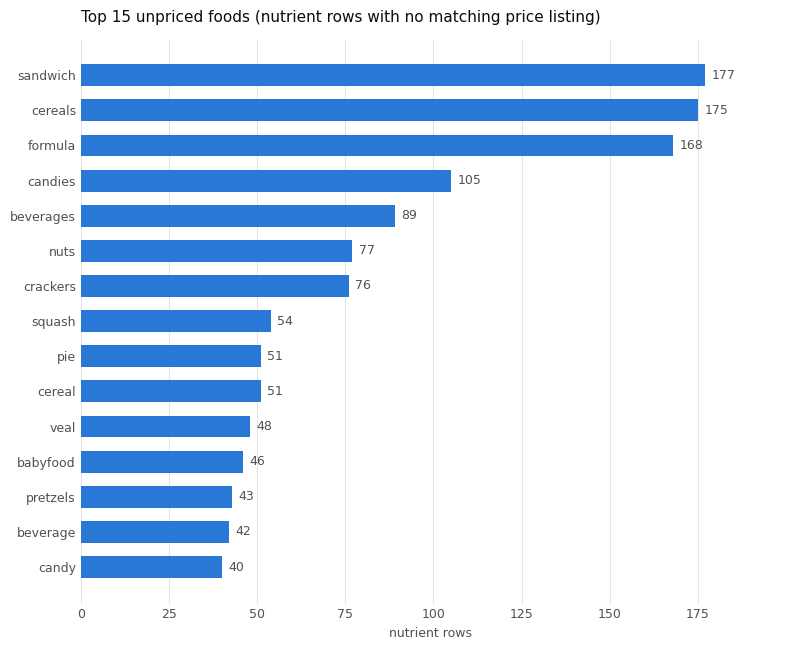

In [68]:
import matplotlib.pyplot as plt

TOP_N = 15
top = unmatched_terms.head(TOP_N)["rows"].iloc[::-1]  # smallest at the bottom of barh

fig, ax = plt.subplots(figsize=(8, 0.36 * len(top) + 1.2))
bars = ax.barh(top.index, top.values, height=0.62, color="#2a78d6")

for bar, value in zip(bars, top.values):
    ax.text(bar.get_width() + max(top.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", ha="left", fontsize=9, color="#52514e")

ax.set_title(f"Top {TOP_N} unpriced foods (nutrient rows with no matching price listing)",
             loc="left", fontsize=11, color="#0b0b0b", pad=12)
ax.set_xlabel("nutrient rows", fontsize=9, color="#52514e")
ax.tick_params(labelsize=9, colors="#52514e", length=0)
ax.set_xlim(0, max(top.values) * 1.12)
ax.xaxis.grid(True, color="#e5e4e0", linewidth=0.8)
ax.set_axisbelow(True)
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)
fig.tight_layout()
plt.show()

In [69]:
unmatched_terms

,rows
head_term,
sandwich,177
cereals,175
formula,168
candies,105
beverages,89
...,...
link,1
limeade,1
limas,1


In [70]:
# # the whole table, not just the head: one row per head term, most frequent first
# unmatched_terms.rename_axis("name").rename(columns={"rows": "occurrences"}).to_csv(
#     "data/output_raw/unmatched_food.csv"
# )

**Item-level coverage** — the items of a row are the product spans the NER
extracted, one price each; how many of them can find a price at all. Buckets:
no item priced, at least one item priced, at least half the items priced, every
item priced.

In [71]:
from statistics import median

priced = price_df["matched_key"] != NOT_MATCH

# a matched listing prices the whole span it matched on, not each of its words:
# "cinnamon rolls" is one item, and a roll's price is not the price of cinnamon.
# The median across the listings sharing a key keeps one odd pack size from
# setting it.
span_prices = defaultdict(list)
for key, price, quantity in zip(
    price_df.loc[priced, "matched_key"],
    price_df.loc[priced, "price_value"],
    price_df.loc[priced, "quantity"],
):
    if pd.isna(price):
        continue
    for variant in key_variants(key):
        span_prices[variant].append((float(price), quantity))


def quantities_of(packs):
    """The pack sizes behind a price, as listed: one string where every listing
    shares a pack, a list where they differ, None where none named one."""
    distinct = list(dict.fromkeys(p for p in packs if p))
    if not distinct:
        return None
    return distinct[0] if len(distinct) == 1 else distinct


def span_price_table(span_prices):
    """{span: [(price, pack)]} as {span: (median price, the packs behind it)}."""
    return {
        span: (round(median(p for p, _ in listings), 2), quantities_of(q for _, q in listings))
        for span, listings in span_prices.items()
    }


food_prices = span_price_table(span_prices)

def price_item(item):
    """The price of the longest suffix of the item some listing reached.

    A suffix for the same reason lookup() takes one: the qualifiers lead
    ("golden layer buttermilk biscuits") and the food itself sits at the end.
    """
    return price_item_from(item, food_prices)


def price_item_from(item, table):
    """price_item(), over an explicit span -> (price, quantity) table."""
    words = item.split()
    for i in range(len(words)):
        hit = table.get(" ".join(words[i:]))
        if hit is not None:
            price, quantity = hit
            return {"price": price, "quantity": quantity}
    return None

# One row = its extracted product spans; one price per span.
items = nutrient_df["product"]
total_items = items.map(len)
n_rows = len(nutrient_df)

# which spans got a price, and at what pack:
# {"chicken breast": {"price": 6.5, "quantity": "500g"}, "rice": {"price": 3.2, "quantity": ["1kg", "5kg"]}}
item_prices = items.map(
    lambda spans: {s: p for s in spans if (p := price_item(s)) is not None}
)
count_mapped = item_prices.map(len)
priced_share = (count_mapped / total_items).where(total_items > 0)

# and the other side: the spans of the row no price listing reaches
unpriced_items = [
    [s for s in spans if s not in prices] for spans, prices in zip(items, item_prices)
]

pd.DataFrame(
    [
        ("no item priced", (count_mapped == 0).sum()),
        ("at least one item priced", (count_mapped > 0).sum()),
        ("at least half the items priced", (priced_share >= 0.5).sum()),
        ("every item priced", (priced_share == 1).sum()),
    ],
    columns=["bucket", "rows"],
).assign(pct=lambda d: (d["rows"] / n_rows).map("{:.1%}".format))

,bucket,rows,pct
0,no item priced,3443,26.3%
1,at least one item priced,9640,73.7%
2,at least half the items priced,9357,71.5%
3,every item priced,7327,56.0%


**Variation-aware pricing** — a nutrient row is priced against the
product it matched, then against the *variation* of that product it names. The
`products` dict the tagging step built is keyed
`{product: (average price, {"origin brand variant": [price, ...]})}`, so once the
product matches, the composite keys under it are the variations to choose
between: the one whose origin / brand / variant the nutrient row also names wins,
and where the row names none of them, the product's average price is what it
gets. Both sides are normalised the same way the product spans already are.
Every price comes out as `{"price": ..., "quantity": ...}`, the quantity being
the pack size(s) of the listings the price was taken over.

In [72]:
from statistics import mean

# variant is the most specific of the three and origin the least, so a variation
# the nutrient row names by variant outranks one it only shares an origin with.
FIELD_WEIGHTS = {"variant": 4, "brand": 2, "origin": 1}


def unpack_product(entry):
    """add_entity_columns returns {product: (average price within its most listed
    pack, that price per 100g / 100ml, the pack it was taken from, the listings)},
    each listing a (price, pack size) pair."""
    if not isinstance(entry, tuple):
        return None, None, "", entry
    if len(entry) == 4:
        return entry
    average, listings = entry
    return average, None, "", listings


def unit_price(price, quantity):
    """A pack price per 100g / 100ml.

    quantity is the magnitude prepare_listings wrote before the crawl was saved
    -- multipacks, carton notes and additive packs already folded in -- so no
    pack label is parsed down here.
    """
    return price / quantity * 100 if quantity else None


def listing_values(entries):
    """The (price, pack) pairs of one variation as (pack prices, per-100 prices,
    packs).

    Each listing is divided by its own pack rather than by the product's modal
    one: a variation is not necessarily sold in the same size as the product.
    """
    prices, units, packs = [], [], []
    for entry in entries:
        # a bare price means the tagging cell above is a stale revision; failing
        # here beats dividing a float by a pack size it never carried
        if not isinstance(entry, (tuple, list)) or len(entry) != 2:
            raise TypeError(
                f"expected (price, pack size) listings, got {entry!r}. "
                "Re-run the tagging cell that builds `products`."
            )
        price, quantity = entry
        if price is None or pd.isna(price):
            continue
        price = float(price)
        prices.append(price)
        packs.append(quantity)
        unit = unit_price(price, quantity)
        if unit is not None:
            units.append(unit)
    return prices, units, packs


def build_product_price_index(products_dict):
    """The products dict as something a nutrient product span can be looked up in.

    index[span] = {"variations": [(qualifiers, required, price, quantity, per_unit)],
                   "average", "quantity", "average_per_unit", "packs",
                   "listings", "unit_listings"}

    The keys are normalised the way both tables already are, and carry every
    suffix of the product name with its plural forms, so a nutrient row naming
    only the food noun still reaches "Holland Potato".
    """
    index = {}
    for product, entry in products_dict.items():
        average, per_unit, pack, listings = unpack_product(entry)
        norm = normalize_description(product)
        if not norm or norm == "nan":  # the rows NER left without a product
            continue
        own = set(norm.split())
        priced, every, weighable = {}, [], 0
        for identifiers, entries in listings.items():
            prices, units, packs = listing_values(entries)
            if not prices:
                continue
            every += prices
            weighable += len(units)
            # the leading words of the product name qualify it too ("Yellow Corn"
            # reached by a bare "corn"), so they are evidence beside the identifiers
            words = frozenset(normalize_description(identifiers).split()) | own
            slot = priced.setdefault(words, ([], [], []))
            slot[0].extend(prices)
            slot[1].extend(units)
            slot[2].extend(packs)
        if not every:
            continue
        avg = round(float(average), 2) if average is not None else round(mean(every), 2)
        unit = round(float(per_unit), 4) if per_unit is not None else None
        for key in product_keys(norm):
            # whatever the lookup matched on is the product's identity, not a
            # variation of it: reaching this entry by "corn" must not let the
            # "corn" of "Sweet Corn" score as a qualifier.
            matched = set(key.split())
            # the rest of the product name is what a shorter span did NOT ask
            # for: "Ice Cream Bars" is reached by "bars", but it is only that
            # row's food if the row names ice cream too. An exact product match
            # requires nothing, so its variations are offered freely.
            required = frozenset(own - matched)
            qualifiers = [
                (w - matched, required, round(median(p), 2), quantities_of(q),
                 round(median(u), 4) if u else None)
                for w, (p, u, q) in priced.items()
            ]
            qualifiers = [q for q in qualifiers if q[0]]
            for span in key_variants(key):
                prev = index.get(span)
                # distinct products reach the same suffix ("pasta sauce", "sauce"),
                # so they are pooled rather than one overwriting the other
                if prev is None:
                    index[span] = {
                        "variations": list(qualifiers),
                        "avg_pool": [(avg, len(every))],
                        "unit_pool": [(unit, len(every))] if unit is not None else [],
                        "packs": {pack} if pack else set(),
                        "listings": len(every),
                        "unit_listings": weighable,
                    }
                else:
                    prev["variations"].extend(qualifiers)
                    prev["avg_pool"].append((avg, len(every)))
                    if unit is not None:
                        prev["unit_pool"].append((unit, len(every)))
                    if pack:
                        prev["packs"].add(pack)
                    prev["listings"] += len(every)
                    prev["unit_listings"] += weighable
    for entry in index.values():
        # a pooled average weights each product by the listings it carried
        pool = entry.pop("avg_pool")
        entry["average"] = round(sum(a * n for a, n in pool) / sum(n for _, n in pool), 2)
        # each product's average was taken within its own most listed pack
        entry["quantity"] = quantities_of(sorted(entry["packs"]))
        # a span every product priced on a count-only pack has no per-unit price
        upool = entry.pop("unit_pool")
        entry["average_per_unit"] = (
            round(sum(u * n for u, n in upool) / sum(n for _, n in upool), 4)
            if upool else None
        )
    return index


def price_for_span(span, tags, index):
    """(price, per_unit, how, variation) for the longest suffix of `span` the
    index knows. price is {"price": ..., "quantity": ...}; per_unit is None
    where the pack was count-only.

    A suffix for the same reason lookup() takes one: the qualifiers lead the span
    and the food itself sits at the end. `tags` are the words the nutrient row
    names beyond the product, per label. Once the product matches, the variation
    repeating the most of them wins -- variant first, then brand, then origin.
    Where the row names none of the three, or none that a variation of this
    product repeats, it gets the product's average price.
    """
    words = span.split()
    for i in range(len(words)):
        entry = index.get(" ".join(words[i:]))
        if entry is None:
            continue
        named = set().union(*tags.values()) if tags else set()
        best, best_rank = None, (0, 0)
        for key_words, required, price, quantity, unit in entry["variations"]:
            # a product the span only reached by suffix has to be named in full
            if not required <= named:
                continue
            hit = [tags[f] & key_words for f in FIELD_WEIGHTS if tags.get(f)]
            score = sum(w for (f, w), h in zip(FIELD_WEIGHTS.items(), hit) if h)
            # how many of the row's words were repeated breaks a tie between two
            # variations it names equally specifically
            rank = (score, sum(map(len, hit)))
            if rank > best_rank:
                best, best_rank = (key_words, price, quantity, unit), rank
        if best is not None:
            key_words, price, quantity, unit = best
            return ({"price": price, "quantity": quantity}, unit, "variation",
                    " ".join(sorted(key_words)))
        return ({"price": entry["average"], "quantity": entry["quantity"]},
                entry["average_per_unit"], "average", NOT_MATCH)
    return None, None, NOT_MATCH, NOT_MATCH


def row_tags(frame, labels=tuple(FIELD_WEIGHTS)):
    """The words each row names per label, normalised. A label the table has no
    column for is empty everywhere -- nutrient_df carries no origin, so that leg
    of the cascade simply never fires until it does."""
    blank = pd.Series([""] * len(frame), index=frame.index)
    cols = [frame.get(f"{label}_norm", blank).fillna("") for label in labels]
    return [dict(zip(labels, (set(v.split()) for v in vals))) for vals in zip(*cols)]


def price_rows(items, tags_per_row, price_span):
    """Every row's spans priced. Returns the four aligned frames the output cells
    below want: the pack price and its quantity per span, the per-100 price per
    span, how each was reached, and which variation it matched."""
    spans = [{s: price_span(s, tags) for s in row} for row, tags in zip(items, tags_per_row)]
    pick = lambda i, keep: pd.Series(
        [{s: r[i] for s, r in row.items() if keep(r)} for row in spans], index=items.index
    )
    return (
        pick(0, lambda r: r[0] is not None),   # {"price", "quantity"}
        pick(1, lambda r: r[1] is not None),   # per 100g / 100ml
        pick(2, lambda r: r[0] is not None),   # route
        pick(3, lambda r: r[3] != NOT_MATCH),  # variation matched
    )


In [73]:
product_price_index = build_product_price_index(products)
nutrient_tags = row_tags(nutrient_df)

# one row = its extracted product spans; one price per span, as before, but the
# span is now priced at the variation the row names rather than at the product
item_prices_var, item_units_var, item_routes, item_variations = price_rows(
    items, nutrient_tags, lambda s, t: price_for_span(s, t, product_price_index)
)
unpriced_items_var = [
    [s for s in spans if s not in prices] for spans, prices in zip(items, item_prices_var)
]
count_mapped_var = item_prices_var.map(len)
priced_share_var = (count_mapped_var / total_items).where(total_items > 0)
# a count-only pack ("6perpack") has no magnitude to divide by, so those items
# carry a pack price but no comparable one; they are left out of a basket total
# rather than stood in for at their pack price
no_unit_var = count_mapped_var - item_units_var.map(len)

routes = pd.Series([r for row in item_routes for r in row.values()])
print(f"rows with at least one item priced: {(count_mapped_var > 0).sum()}/{n_rows}"
      f" = {(count_mapped_var > 0).mean():.1%}")
print(f"rows fully priced:                  {(priced_share_var == 1).sum()}/{n_rows}"
      f" = {(priced_share_var == 1).mean():.1%}")
print(f"\nitems priced at a named variation:  {(routes == 'variation').sum()}"
      f" = {(routes == 'variation').mean():.1%} of priced items")
print(f"items priced at the product average: {(routes == 'average').sum()}")
print(f"\nitems with a per-100g / per-100ml price: {item_units_var.map(len).sum()}"
      f"/{count_mapped_var.sum()}")
print(f"items on a count-only pack, left out of the basket total: {no_unit_var.sum()}")
print(f"rows losing at least one item that way: {(no_unit_var > 0).sum()}")

# the span-median baseline of the cell above, for what the variation split buys
pd.DataFrame(
    [("span median (baseline)", (count_mapped > 0).sum(), (priced_share == 1).sum()),
     ("product + variation", (count_mapped_var > 0).sum(), (priced_share_var == 1).sum())],
    columns=["pricing", "rows with an item priced", "rows fully priced"],
)


rows with at least one item priced: 9498/13083 = 72.6%
rows fully priced:                  7234/13083 = 55.3%

items priced at a named variation:  2414 = 18.4% of priced items
items priced at the product average: 10727

items with a per-100g / per-100ml price: 13141/13141
items on a count-only pack, left out of the basket total: 0
rows losing at least one item that way: 0


,pricing,rows with an item priced,rows fully priced
0,span median (baseline),9640,7327
1,product + variation,9498,7234


In [74]:
# What the cascade actually chose: the rows that named a variation and got it.
picked = pd.DataFrame(
    [
        (fdc, desc[:60], span, prices[span]["price"], prices[span]["quantity"],
         variations.get(span, NOT_MATCH))
        for fdc, desc, prices, routes_, variations in zip(
            nutrient_df["fdc_id"], nutrient_df["description"],
            item_prices_var, item_routes, item_variations,
        )
        for span, how in routes_.items()
        if how == "variation"
    ],
    columns=["fdc_id", "description", "item", "price", "quantity", "matched variation"],
)
print(f"{len(picked)} items priced at a variation")
picked.head(20)


2414 items priced at a variation


,fdc_id,description,item,price,quantity,matched variation
0,167557,"Snacks, rice cakes, brown rice, sesame seed",rice,6.95,2500.0,brown fairprice thailand unpolished
1,167572,"Ice creams, vanilla, light",ice creams,14.77,473.0,dazs haagen vanilla
2,167573,"Ice creams, vanilla, rich",ice creams,14.77,473.0,dazs haagen vanilla
3,167575,"Ice creams, vanilla",ice creams,14.77,473.0,dazs haagen vanilla
4,167576,"Ice creams, vanilla, light, soft-serve",ice creams,14.77,473.0,dazs haagen vanilla
5,167585,"Ice creams, chocolate, light",ice creams,10.20,"[473.0, 100.0]",belgium chocolate dazs haagen
6,167615,"Fish, salmon, king, chinook, smoked, brined (A...",salmon,8.38,75.0,black fassler pepper smoked
7,167645,"Fish, salmon, red, (sockeye), canned, smoked (...",salmon,8.38,75.0,black fassler pepper smoked
8,167647,"Fish, salmon, king, with skin, kippered, (Alas...",salmon,14.37,150.0,canada fresh king port65
9,167651,"Buffalo, free range, top round steak, cooked (...",steak,11.90,400.0,free range tegel


In [75]:
priced_per_row = nutrient_df[["fdc_id", "description"]].assign(
    product=nutrient_df["product"],
    item_prices=item_prices_var,
    item_unit_prices=item_units_var,
    item_routes=item_routes,
    matched_variations=item_variations,
    unpriced_items=unpriced_items_var,
    priced_items=count_mapped_var,
    total_items=total_items,
    priced_share=priced_share_var,
    items_without_unit_price=no_unit_var,
    adj=nutrient_df["adj"],
    verb=nutrient_df["verb"],
)
# every item's pack price added up. Kept for continuity, but the pack differs per
# product -- a 5kg bag of rice beside a 90g pack of chicken -- so this column is
# not a comparable total. basket_per_100 below is the one to read.
priced_per_row["total_price"] = (
    priced_per_row["item_prices"].map(lambda p: round(sum(i["price"] for i in p.values()), 2))
    .where(priced_per_row["priced_share"] == 1, 0)
)
# the same total over the per-100g / per-100ml prices, which are comparable
# between products. An item on a count-only pack has none and is simply absent
# from the sum -- items_without_unit_price says how many a row lost that way.
priced_per_row["basket_per_100"] = (
    priced_per_row["item_unit_prices"].map(lambda p: round(sum(p.values()), 2))
    .where(priced_per_row["priced_share"] == 1, 0)
)
nutrient_columns = ['protein_g','fat_g','carb_g','energy_kcal','fiber_g',
                    'sodium_mg','cholesterol_mg','satfat_g','sugars_g']
for nutrient_col in nutrient_columns:
    priced_per_row[nutrient_col] = nutrient_df[nutrient_col]

# drop ones with no item priced
priced_per_row = priced_per_row.loc[priced_per_row["priced_items"] > 0]

priced_per_row.sort_values("priced_share").head(30)

,fdc_id,description,product,item_prices,item_unit_prices,item_routes,matched_variations,unpriced_items,priced_items,total_items,...,basket_per_100,protein_g,fat_g,carb_g,energy_kcal,fiber_g,sodium_mg,cholesterol_mg,satfat_g,sugars_g
3722,171363,"Babyfood, cereal, oatmeal, with applesauce and...","[babyfood, cereal, oatmeal, applesauce, bananas]","{'bananas': {'price': 4.93, 'quantity': 820.0}}",{'bananas': 0.6016},{'bananas': 'average'},{},"[babyfood, cereal, oatmeal, applesauce]",1,5,...,0.0,0.89,0.89,16.03,76.0,0.9,4.0,0.0,0.126,8.85
3721,171362,"Babyfood, cereal, oatmeal, with applesauce and...","[babyfood, cereal, oatmeal, applesauce, bananas]","{'bananas': {'price': 4.93, 'quantity': 820.0}}",{'bananas': 0.6016},{'bananas': 'average'},{},"[babyfood, cereal, oatmeal, applesauce]",1,5,...,0.0,0.89,0.89,15.62,75.0,0.9,4.0,0.0,0.125,8.85
2034,169628,"Candies, HERSHEY, REESESTICKS crispy wafers, p...","[candies, reesesticks, wafers, peanut butter, ...","{'peanut butter': {'price': 7.47, 'quantity': ...",{'peanut butter': 3.9186},{'peanut butter': 'average'},{},"[candies, reesesticks, wafers, milk chocolate]",1,5,...,0.0,9.53,31.34,55.38,521.0,3.3,264.0,6.0,13.210,40.33
3319,170949,"Babyfood, fruit, applesauce and cherries, stra...","[babyfood, fruit, applesauce, cherries]","{'fruit': {'price': 4.0, 'quantity': [400.0, 5...",{'fruit': 0.875},{'fruit': 'average'},{},"[babyfood, applesauce, cherries]",1,4,...,0.0,0.00,0.00,14.10,51.0,1.1,1.0,0.0,0.000,10.81
6803,174506,"Chicken, broiler, rotisserie, BBQ, back meat only","[chicken, broiler, rotisserie, bbq]","{'chicken': {'price': 9.72, 'quantity': [100.0...",{'chicken': 1.7085},{'chicken': 'average'},{},"[broiler, rotisserie, bbq]",1,4,...,0.0,21.85,13.87,0.31,212.0,0.0,563.0,117.0,3.613,0.31
2092,169687,"Snacks, KELLOGG, KELLOGG'S RICE KRISPIES TREAT...","[snacks, rice krispies, treats, squares]","{'snacks': {'price': 7.47, 'quantity': 350.0}}",{'snacks': 2.1333},{'snacks': 'average'},{},"[rice krispies, treats, squares]",1,4,...,0.0,3.40,9.00,80.50,417.0,0.0,351.0,0.0,1.400,19.36
3725,171366,"Babyfood, cereal, egg yolks and bacon, junior","[babyfood, cereal, egg yolks, bacon]","{'bacon': {'price': 7.27, 'quantity': [200.0, ...",{'bacon': 2.8701},{'bacon': 'average'},{},"[babyfood, cereal, egg yolks]",1,4,...,0.0,2.50,5.00,6.20,79.0,0.9,48.0,94.0,1.640,NaN
3320,170950,"Babyfood, fruit, applesauce and cherries, junior","[babyfood, fruit, applesauce, cherries]","{'fruit': {'price': 4.0, 'quantity': [400.0, 5...",{'fruit': 0.875},{'fruit': 'average'},{},"[babyfood, applesauce, cherries]",1,4,...,0.0,0.00,0.00,14.10,51.0,1.1,1.0,0.0,0.000,10.61
3871,171516,"Chicken, broiler, rotisserie, BBQ, wing, meat ...","[chicken, broiler, rotisserie, bbq]","{'chicken': {'price': 7.1, 'quantity': 1000.0}}",{'chicken': 0.71},{'chicken': 'variation'},{'chicken': 'hego stick wing'},"[broiler, rotisserie, bbq]",1,4,...,0.0,28.34,7.79,0.54,186.0,0.0,725.0,134.0,2.134,0.53
3491,171126,"Chicken, broiler, rotisserie, BBQ, drumstick, ...","[chicken, broiler, rotisserie, bbq]","{'chicken': {'price': 9.72, 'quantity': [100.0...",{'chicken': 1.7085},{'chicken': 'average'},{},"[broiler, rotisserie, bbq]",1,4,...,0.0,25.65,11.46,0.12,206.0,0.0,392.0,149.0,2.855,0.12


In [76]:
priced_per_row.to_csv("data/output_final/price_mapped_nutrients.csv", index=False)

**Handled remaining unmatched food**

In [77]:
unmatched_terms

,rows
head_term,
sandwich,177
cereals,175
formula,168
candies,105
beverages,89
...,...
link,1
limeade,1
limas,1


In [78]:
frequent_threshold = 20
frequent = unmatched_terms.loc[unmatched_terms["rows"] >= frequent_threshold]

covered = frequent["rows"].sum()
unmatched_rows = unmatched_terms["rows"].sum()

print(f"terms with >= {frequent_threshold} rows: {len(frequent)}/{len(unmatched_terms)}")
print(f"rows they account for: {covered}/{unmatched_rows} = {covered / unmatched_rows:.1%} of unmatched")
print(f"                       {covered}/{len(nutrient_df)} = {covered / len(nutrient_df):.1%} of all nutrient rows")

terms with >= 20 rows: 29/603
rows they account for: 1606/3302 = 48.6% of unmatched
                       1606/13083 = 12.3% of all nutrient rows


In [79]:
frequent.to_csv("data/output_raw/frequent_unmatched_food.csv")

At this stage, run **fairprice_unmatched_crawler.py** to crawl those unmatched.
After completing, read DataFrame from **data/output_raw/raw_unmatched_food_prices.csv**

In [80]:
# same preparation as the aisle crawl: quantity parsed into its magnitude,
# count-only packs dropped
unmatched_processed_df = prepare_listings(
    pd.read_csv("data/output_raw/raw_unmatched_food_prices.csv")
)

dropping 55 of 528 listings on a count-only pack


In [81]:
# a separate name: `products` is the aisle crawl's index and the merge below
# still needs it, so the term crawl's must not land on top of it
unmatched_processed_df, unmatched_products = add_entity_columns(
    unmatched_processed_df, NER_LABELS
)

tagging:   0%|          | 0/15 [00:00<?, ?it/s]

**Pricing the unmatched terms** — the crawl is one search per head term of
`unmatched_terms`, so a listing prices the term it was fetched for and the
spans that term heads. Those spans are folded into the price table the aisle
crawl built, and the nutrient rows that had no priced item are re-checked
against the merged table.

In [82]:
# Same prep as price_df in the mapping section: the NER product span, the raw
# name where NER found none, normalised the same way.
unmatched_processed_df["product"] = (
    unmatched_processed_df["product"].fillna("").astype(str).str.strip()
    .where(lambda s: s != "", unmatched_processed_df["name"].fillna("").astype(str))
)
unmatched_processed_df["product_norm"] = unmatched_processed_df["product"].map(
    normalize_description
)

crawled_terms = set(unmatched_terms.index)


def term_keys(norm, term):
    words = norm.split()
    if not words:
        return set()
    variants = key_variants(term)
    if words[-1] not in variants:
        if len(words) > 1 and "".join(words[-2:]) in variants:
            words = words[:-2] + [term]
        else:
            return set()
    return {" ".join(words[i:]) for i in range(len(words))}


unmatched_span_prices = defaultdict(list)
on_term = 0
for term, norm, price, quantity in zip(
    unmatched_processed_df["term"],
    unmatched_processed_df["product_norm"],
    unmatched_processed_df["price_value"],
    unmatched_processed_df["quantity"],
):
    # a term the current unmatched_terms no longer lists is a leftover from an
    # earlier crawl and prices nothing here
    if term not in crawled_terms or pd.isna(price):
        continue
    keys = term_keys(norm, term)
    on_term += bool(keys)
    for key in keys:
        for variant in key_variants(key):
            unmatched_span_prices[variant].append((float(price), quantity))

# median for the same reason the aisle crawl takes one: a single odd pack size
# should not set the price of a span
unmatched_food_prices = span_price_table(unmatched_span_prices)

crawl_terms = sorted(set(unmatched_processed_df["term"]) & crawled_terms)
print(f"listings on term: {on_term}/{len(unmatched_processed_df)}")
print(f"terms priced: {sum(t in unmatched_food_prices for t in crawl_terms)}/{len(crawl_terms)}"
      f" crawled ({len(crawled_terms)} unmatched terms in all)")
print(f"spans priced: {len(unmatched_food_prices)}")

# a term with no price of its own is one the search never answered with that
# food -- the "sandwich" results are sandwich biscuits, which price biscuits
pd.Series({t: unmatched_food_prices.get(t) for t in crawl_terms}, name="span price")

listings on term: 165/473
terms priced: 19/28 crawled (603 unmatched terms in all)
spans priced: 313


babyfood                                    (3.48, [120.0, 80.0])
beverage                                (17.55, [2500.0, 1320.0])
beverages                               (17.55, [2500.0, 1320.0])
biscuit         (4.05, [193.2, 360.0, 260.0, 600.0, 234.0, 50....
candies                                                      None
candy           (2.8, [150.0, 100.0, 90.0, 105.3, 175.5, 200.0...
cereal          (6.5, [300.0, 439.0, 382.0, 396.0, 70.0, 150.0...
cereals         (6.5, [300.0, 439.0, 382.0, 396.0, 70.0, 150.0...
cheeseburger                                                 None
crackers        (2.5, [225.0, 428.0, 250.0, 104.0, 416.0, 200....
dip                                  (6.1, [453.0, 439.4, 250.0])
formula         (73.8, [250.0, 1650.0, 800.0, 900.0, 1800.0, 1...
hamburger                                                    None
muffin                                       (1.3, [60.0, 460.0])
muffins                                      (1.3, [60.0, 460.0])
nectar    

In [83]:
def merge_price_indexes(primary, secondary):
    """`primary` wins the spans both know, `secondary` only fills the gaps: an
    aisle listing is a real listing of that food, while a term-crawl listing is
    whatever the search returned for the term."""
    merged = {span: dict(entry) for span, entry in secondary.items()}
    merged.update({span: dict(entry) for span, entry in primary.items()})
    return merged


# the term crawl's listings are tagged and clustered the same way, so they index
# into variations as well: a term result naming a brand still prices that brand
unmatched_price_index = build_product_price_index(unmatched_products)
merged_price_index = merge_price_indexes(product_price_index, unmatched_price_index)


def price_span_merged(span, tags):
    """The merged product index first, then the term table of the cell above for
    the spans no product entry reaches at all."""
    price, unit, how, variation = price_for_span(span, tags, merged_price_index)
    if price is not None:
        return price, unit, how, variation
    price = price_item_from(span, unmatched_food_prices)
    if price is not None:
        # that table is a median over spans, with no pack behind it to divide by
        return price, None, "term crawl", NOT_MATCH
    return None, None, NOT_MATCH, NOT_MATCH


item_prices_merged, item_units_merged, item_routes_merged, item_variations_merged = (
    price_rows(items, nutrient_tags, price_span_merged)
)
unpriced_items_merged = [
    [s for s in spans if s not in prices]
    for spans, prices in zip(items, item_prices_merged)
]
count_mapped_merged = item_prices_merged.map(len)
priced_share_merged = (count_mapped_merged / total_items).where(total_items > 0)
no_unit_merged = count_mapped_merged - item_units_merged.map(len)

recovered = (count_mapped_var == 0) & (count_mapped_merged > 0)
print(f"rows recovered: {recovered.sum()}/{(count_mapped_var == 0).sum()} that had no item priced")
print(f"at least one item priced: {(count_mapped_var > 0).sum()} -> {(count_mapped_merged > 0).sum()}"
      f" = {(count_mapped_merged > 0).mean():.1%} of nutrient rows")
print(f"every item priced: {(priced_share_var == 1).sum()} -> {(priced_share_merged == 1).sum()}"
      f" = {(priced_share_merged == 1).mean():.1%} of nutrient rows")

routes_merged = pd.Series([r for row in item_routes_merged for r in row.values()])
print(f"\nitems by route:\n{routes_merged.value_counts().to_string()}")
print(f"\nitems with no per-100 price (count-only pack or term crawl): {no_unit_merged.sum()}")

# which of the crawled terms actually bought coverage back
nutrient_df.loc[recovered].groupby("head_term").size().sort_values(ascending=False).head(15)

rows recovered: 1160/3585 that had no item priced
at least one item priced: 9498 -> 10658 = 81.5% of nutrient rows
every item priced: 7234 -> 8486 = 64.9% of nutrient rows

items by route:
average       12123
variation      2562
term crawl      233

items with no per-100 price (count-only pack or term crawl): 233


head_term
cereals      177
formula      168
nuts          91
beverages     85
crackers      78
pie           50
cereal        49
babyfood      42
beverage      42
candy         40
muffin        36
dip           31
popcorn       29
water         26
soymilk       25
dtype: int64

In [84]:
priced_per_row = nutrient_df[["fdc_id", "description"]].assign(
    product=nutrient_df["product"],
    item_prices=item_prices_merged,
    item_unit_prices=item_units_merged,
    item_routes=item_routes_merged,
    matched_variations=item_variations_merged,
    unpriced_items=unpriced_items_merged,
    priced_items=count_mapped_merged,
    total_items=total_items,
    priced_share=priced_share_merged,
    items_without_unit_price=no_unit_merged,
    adj=nutrient_df["adj"],
    verb=nutrient_df["verb"],
)
# every item's pack price added up. Kept for continuity, but the pack differs per
# product -- a 5kg bag of rice beside a 90g pack of chicken -- so this column is
# not a comparable total. basket_per_100 below is the one to read.
priced_per_row["total_price"] = (
    priced_per_row["item_prices"].map(lambda p: round(sum(i["price"] for i in p.values()), 2))
    .where(priced_per_row["priced_share"] == 1, 0)
)
# the same total over the per-100g / per-100ml prices, which are comparable
# between products. An item on a count-only pack has none and is simply absent
# from the sum -- items_without_unit_price says how many a row lost that way.
priced_per_row["basket_per_100"] = (
    priced_per_row["item_unit_prices"].map(lambda p: round(sum(p.values()), 2))
    .where(priced_per_row["priced_share"] == 1, 0)
)
nutrient_columns = ['protein_g','fat_g','carb_g','energy_kcal','fiber_g',
                    'sodium_mg','cholesterol_mg','satfat_g','sugars_g']
for nutrient_col in nutrient_columns:
    priced_per_row[nutrient_col] = nutrient_df[nutrient_col]

# drop ones with no item priced
priced_per_row = priced_per_row.loc[priced_per_row["priced_items"] > 0]

priced_per_row.to_csv("data/output_final/price_mapped_nutrients.csv", index=False)
priced_per_row.sort_values("priced_share").head(30)

,fdc_id,description,product,item_prices,item_unit_prices,item_routes,matched_variations,unpriced_items,priced_items,total_items,...,basket_per_100,protein_g,fat_g,carb_g,energy_kcal,fiber_g,sodium_mg,cholesterol_mg,satfat_g,sugars_g
5972,173664,"Alcoholic beverage, distilled, all (gin, rum, ...","[beverage, gin, rum, vodka, whiskey]","{'beverage': {'price': 17.55, 'quantity': 2500...",{'beverage': 0.702},{'beverage': 'average'},{},"[gin, rum, vodka, whiskey]",1,5,...,0.0,0.00,0.00,0.00,295.0,0.0,1.0,0.0,0.000,NaN
4274,171920,"Alcoholic beverage, distilled, all (gin, rum, ...","[beverage, gin, rum, vodka, whiskey]","{'beverage': {'price': 17.55, 'quantity': 2500...",{'beverage': 0.702},{'beverage': 'average'},{},"[gin, rum, vodka, whiskey]",1,5,...,0.0,0.00,0.00,0.00,263.0,0.0,1.0,0.0,0.000,0.00
4273,171919,"Alcoholic beverage, distilled, all (gin, rum, ...","[beverage, gin, rum, vodka, whiskey]","{'beverage': {'price': 17.55, 'quantity': 2500...",{'beverage': 0.702},{'beverage': 'average'},{},"[gin, rum, vodka, whiskey]",1,5,...,0.0,0.00,0.00,0.10,250.0,0.0,1.0,0.0,0.000,0.00
5971,173663,"Alcoholic beverage, distilled, all (gin, rum, ...","[beverage, gin, rum, vodka, whiskey]","{'beverage': {'price': 17.55, 'quantity': 2500...",{'beverage': 0.702},{'beverage': 'average'},{},"[gin, rum, vodka, whiskey]",1,5,...,0.0,0.00,0.00,0.00,275.0,0.0,1.0,0.0,0.000,NaN
7111,174815,"Alcoholic beverage, distilled, all (gin, rum, ...","[beverage, gin, rum, vodka, whiskey]","{'beverage': {'price': 17.55, 'quantity': 2500...",{'beverage': 0.702},{'beverage': 'average'},{},"[gin, rum, vodka, whiskey]",1,5,...,0.0,0.00,0.00,0.00,231.0,0.0,1.0,0.0,0.000,0.00
6922,174625,"Cereals, QUAKER, Instant Oatmeal, raisins, dat...","[cereals, oatmeal, raisins, dates walnuts]","{'cereals': {'price': 6.39, 'quantity': [300.0...",{'cereals': 2.0041},{'cereals': 'average'},{},"[oatmeal, raisins, dates walnuts]",1,4,...,0.0,8.82,6.98,72.41,371.0,6.9,516.0,0.0,1.070,30.85
5503,173170,"Beverages, SLIMFAST, Meal replacement, High P...","[beverages, slimfast, meal replacement, protei...","{'beverages': {'price': 17.55, 'quantity': 250...",{'beverages': 0.702},{'beverages': 'average'},{},"[slimfast, meal replacement, protein shake]",1,4,...,0.0,6.59,3.38,0.85,61.0,0.4,72.0,4.0,0.508,0.60
3871,171516,"Chicken, broiler, rotisserie, BBQ, wing, meat ...","[chicken, broiler, rotisserie, bbq]","{'chicken': {'price': 7.1, 'quantity': 1000.0}}",{'chicken': 0.71},{'chicken': 'variation'},{'chicken': 'hego stick wing'},"[broiler, rotisserie, bbq]",1,4,...,0.0,28.34,7.79,0.54,186.0,0.0,725.0,134.0,2.134,0.53
6803,174506,"Chicken, broiler, rotisserie, BBQ, back meat only","[chicken, broiler, rotisserie, bbq]","{'chicken': {'price': 9.72, 'quantity': [100.0...",{'chicken': 1.7085},{'chicken': 'average'},{},"[broiler, rotisserie, bbq]",1,4,...,0.0,21.85,13.87,0.31,212.0,0.0,563.0,117.0,3.613,0.31
3879,171524,"Chicken, broiler, rotisserie, BBQ, skin","[chicken, broiler, rotisserie, bbq]","{'chicken': {'price': 9.72, 'quantity': [100.0...",{'chicken': 1.7085},{'chicken': 'average'},{},"[broiler, rotisserie, bbq]",1,4,...,0.0,15.19,35.15,0.70,378.0,0.0,335.0,120.0,9.333,0.70
